In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import requests

url = "https://urlhaus.abuse.ch/downloads/text/"
response = requests.get(url, stream=True)

with open("urlhaus_full_urls.txt", "wb") as file:
    for chunk in response.iter_content(chunk_size=8192):
        file.write(chunk)

print("Done!")

Done!


In [4]:
print("URLhaus...")

df_urlhaus = pd.read_csv("urlhaus_full_urls.txt", 
                         header=None, 
                         names=['url'], 
                         comment='#', 
                         on_bad_lines='skip')

df_urlhaus['type'] = 'malware'

print(f"{df_urlhaus.shape[0]} URL loaded")

URLhaus...
76111 URL loaded


In [5]:
df = pd.read_csv(r"/kaggle/input/datasets/sid321axn/malicious-urls-dataset/malicious_phish.csv")

In [6]:
df_new = pd.read_csv(r"/kaggle/input/datasets/siddharthkumar25/malicious-and-benign-urls/urldata.csv")

df_new_benign = df_new[df_new['label'] == 'benign'].copy()
df_new_benign = df_new_benign[['url']]
df_new_benign['type'] = 'benign'

df_comb = pd.concat([df, df_new_benign], ignore_index=True)
df_comb.drop_duplicates(subset=['url'], inplace=True)

In [7]:
df_combined = pd.concat([df_comb, df_urlhaus], ignore_index=True)

df_combined.drop_duplicates(subset=['url'], inplace=True)
df_combined.reset_index(drop=True, inplace=True)

print(f"Size of data: {df_combined.shape[0]} rows.")

Size of data: 1062964 rows.


In [8]:
df = df_combined
df

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement
...,...,...
1062959,https://www.dropbox.com/s/dl/dqrsgzlf8jeefw0/F...,malware
1062960,https://www.dropbox.com/s/dl/g4is5u674v6l2yy/F...,malware
1062961,http://crimefreesoftware.com/MC_setup.exe,malware
1062962,http://robertrowe.com/DOC/Past-Due-invoice/,malware


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062964 entries, 0 to 1062963
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   url     1062964 non-null  object
 1   type    1062964 non-null  object
dtypes: object(2)
memory usage: 16.2+ MB


In [10]:
from sklearn.preprocessing import LabelEncoder
import joblib

df = df.copy()

encoder = LabelEncoder()
df['type_code'] = encoder.fit_transform(df['type'])

joblib.dump(encoder, 'label_encoder.pkl')

mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

class_names = ['benign', 'defacement', 'malware', 'phishing']

print(f"The encoding:\n{mapping}")

The encoding:
{'benign': np.int64(0), 'defacement': np.int64(1), 'malware': np.int64(2), 'phishing': np.int64(3)}


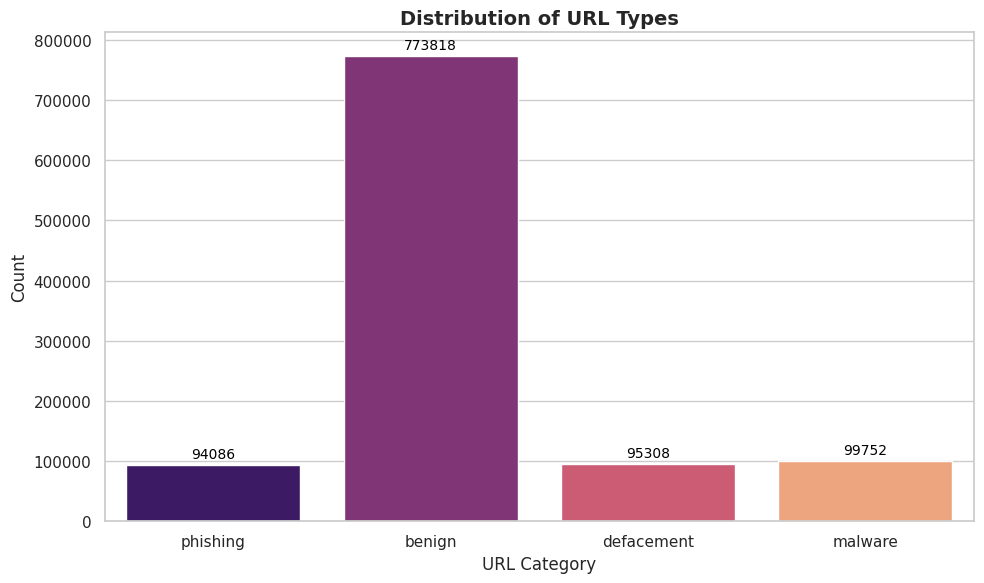

In [11]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6)) 

ax = sns.countplot(data=df, x='type', hue='type', palette='magma', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of URL Types', fontsize=14, weight='bold')
plt.xlabel('URL Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

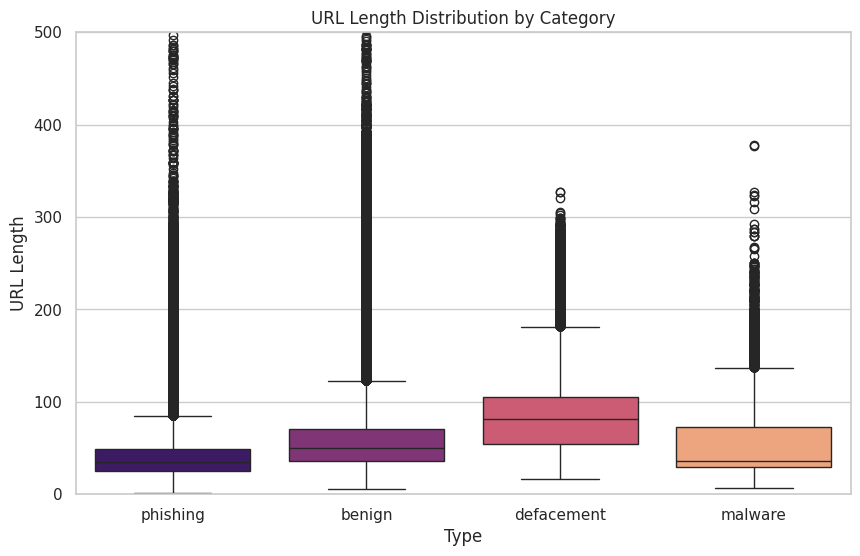

               count       mean        std   min   25%   50%    75%     max
type                                                                       
benign      773818.0  58.035742  37.107872   6.0  36.0  50.0   71.0  2175.0
defacement   95308.0  86.128405  41.854570  17.0  54.0  81.0  105.0   327.0
malware      99752.0  52.780826  31.276612   7.0  30.0  36.0   73.0   378.0
phishing     94086.0  45.853623  43.748433   1.0  25.0  35.0   49.0  1779.0


In [12]:
df_box = df.copy()
df_box['url_length'] = df_box['url'].apply(len)

plt.figure(figsize=(10, 6))

sns.boxplot(x='type', y='url_length', data=df_box, palette='magma', hue='type', legend=False)

plt.title('URL Length Distribution by Category')
plt.xlabel('Type')
plt.ylabel('URL Length')

plt.ylim(0, 500) 
plt.show()

print(df_box.groupby('type')['url_length'].describe())

In [13]:
import re
import math
from collections import Counter
from urllib.parse import urlparse

def calculate_entropy(text):
    if not text:
        return 0
    entropy = 0
    for x in Counter(text).values():
        p_x = float(x) / len(text)
        entropy -= p_x * math.log(p_x, 2)
    return entropy

ipv4_pattern = re.compile(r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.){3}([01]?\d\d?|2[0-4]\d|25[0-5])')
ipv6_pattern = re.compile(r'([0-9a-fA-F]{1,4}:){7,7}[0-9a-fA-F]{1,4}|([0-9a-fA-F]{1,4}:){1,7}:|([0-9a-fA-F]{1,4}:){1,6}:[0-9a-fA-F]{1,4}')
digit_pattern = re.compile(r'\d')
letter_pattern = re.compile(r'[a-zA-Z]')

suspicious_words = ['secure', 'account', 'update', 'login', 'verify', 'bank', 'free', 'bonus', 'admin', 'service', 'client']
shorteners = ['bit.ly', 'tinyurl.com', 'goo.gl', 't.co', 'ow.ly', 'is.gd', 'buff.ly', 'bit.do']

def Extract_features(url):
    url = str(url)
    parsed_url = urlparse(url)
    
    features = {}

    features['url_length'] = len(url)
    features['hostname_length'] = len(parsed_url.netloc)
    features['path_length'] = len(parsed_url.path)
    
    features['url_entropy'] = calculate_entropy(url)
    
    features['count_dots'] = url.count('.')
    features['count_hyphens'] = url.count('-')
    features['count_at'] = url.count('@')
    features['count_question_marks'] = url.count('?')
    features['count_equals'] = url.count('=')
    features['count_ampersands'] = url.count('&')
    features['count_dirs'] = parsed_url.path.count('/')
    
    features['count_subdomains'] = parsed_url.netloc.count('.')
    
    features['has_suspicious_words'] = 1 if any(word in url.lower() for word in suspicious_words) else 0

    features['is_shortened'] = 1 if any(short in parsed_url.netloc for short in shorteners) else 0
    
    features['has_non_standard_port'] = 1 if parsed_url.port not in [None, 80, 443] else 0
    
    features['has_ip'] = 1 if (ipv4_pattern.search(url) or ipv6_pattern.search(url)) else 0
    
    features['count_digits'] = len(digit_pattern.findall(url))
    features['count_letters'] = len(letter_pattern.findall(url))
    features['digit_letter_ratio'] = features['count_digits'] / (features['count_letters'] + 1)
    
    return features

print("Feature extraction...")

features_list = [Extract_features(url) for url in df['url']]
extracted_features_df = pd.DataFrame(features_list)

df = pd.concat([df.reset_index(drop=True), extracted_features_df.reset_index(drop=True)], axis=1)

print("Done, the features extracted")

Feature extraction...
Done, the features extracted


In [14]:
from sklearn.model_selection import train_test_split

train_Drop_columns = ['type', 'type_code']

X = df.drop(columns=train_Drop_columns)
y = df['type_code']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (850371, 20)
Test shape: (212593, 20)


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp 

def url_tokenizer(url):
    tokens = re.split(r'[/\-.\?=&_:]', str(url))
    stopwords = ['www', 'com', 'org', 'net', 'info']
    return [token.lower() for token in tokens if token and token.lower() not in stopwords]

print("TF-IDF...")

tfidf = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=10000, dtype=np.float32)

X_train_tfidf = tfidf.fit_transform(X_train['url'])
X_test_tfidf = tfidf.transform(X_test['url'])

X_train_manual = X_train.drop(columns=['url'])
X_test_manual = X_test.drop(columns=['url'])

X_train_final = sp.hstack([X_train_manual.values, X_train_tfidf], format='csr')
X_test_final = sp.hstack([X_test_manual.values, X_test_tfidf], format='csr')

print("TF-IDF Done.")

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

all_feature_names = list(X_train_manual.columns) + list(tfidf.get_feature_names_out())
all_feature_names = [re.sub(r'[\[\]<]', '_', name) for name in all_feature_names]

joblib.dump(all_feature_names, 'feature_names.pkl')

print("'tfidf_vectorizer.pkl' and 'feature_names.pkl' had been seaved successfully.")

TF-IDF...
TF-IDF Done.
'tfidf_vectorizer.pkl' and 'feature_names.pkl' had been seaved successfully.


In [16]:
print("Train data shape:", X_train_final.shape)
print()

first_10_rows = X_train_final[:10].toarray()

display(pd.DataFrame(first_10_rows, columns=all_feature_names))

Train data shape: (850371, 10019)



,url_length,hostname_length,path_length,url_entropy,count_dots,count_hyphens,count_at,count_question_marks,count_equals,count_ampersands,...,zon,zon.,zon.c,zp,zs,zu,zw,zx,zy,zz
0,35.0,10.0,17.0,4.286147,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,43.0,0.0,43.0,4.359420,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,36.0,16.0,13.0,3.884795,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,66.0,29.0,16.0,4.313260,4.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,31.0,0.0,31.0,3.864698,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,90.0,15.0,68.0,4.126987,2.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,53.0,9.0,37.0,4.727552,2.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,66.0,0.0,66.0,4.341309,1.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,36.0,0.0,29.0,4.384795,2.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,35.0,18.0,9.0,4.286147,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() 

X_train_manual_scaled = scaler.fit_transform(X_train_manual)
X_test_manual_scaled = scaler.transform(X_test_manual)

X_train_final = sp.hstack([X_train_manual_scaled, X_train_tfidf], format='csr')
X_test_final = sp.hstack([X_test_manual_scaled, X_test_tfidf], format='csr')

joblib.dump(scaler, 'minmax_scaler.pkl')

['minmax_scaler.pkl']

In [18]:
print(y_train.value_counts(normalize=True) * 100)

type_code
0    72.798108
2     9.384375
1     8.966204
3     8.851313
Name: proportion, dtype: float64


In [19]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_Under, y_train_Under = rus.fit_resample(X_train_final, y_train)

print("Before:", y_train.value_counts())
print("\nAfter UnderSampling:", pd.Series(y_train_Under).value_counts())

Before: type_code
0    619054
2     79802
1     76246
3     75269
Name: count, dtype: int64

After UnderSampling: type_code
0    75269
1    75269
2    75269
3    75269
Name: count, dtype: int64


In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
X_train_final = X_train_final.astype(np.float32)
X_test_final = X_test_final.astype(np.float32)

y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)

In [22]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1.0,               
    dual=False,          
    class_weight=None,   
    max_iter=2000,      
    random_state=42
)

svm.fit(X_train_final, y_train)

pred_svm = svm.predict(X_test_final)
acc_svm = accuracy_score(y_test, pred_svm)

print(f"SVM Accuracy: {acc_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred_svm, target_names=class_names))

SVM Accuracy: 0.9785

Classification Report:
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99    154764
  defacement       0.99      1.00      0.99     19062
     malware       0.99      0.98      0.98     19950
    phishing       0.91      0.85      0.88     18817

    accuracy                           0.98    212593
   macro avg       0.97      0.95      0.96    212593
weighted avg       0.98      0.98      0.98    212593



In [23]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1.0,           
    dual=False,        
    class_weight=None,  
    max_iter=2000,       
    random_state=42
)

svm.fit(X_train_Under, y_train_Under)

pred_svm = svm.predict(X_test_final)
acc_svm2 = accuracy_score(y_test, pred_svm)

print(f"SVM Accuracy: {acc_svm2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred_svm, target_names=class_names))

SVM Accuracy: 0.9634

Classification Report:
              precision    recall  f1-score   support

      benign       0.99      0.96      0.98    154764
  defacement       0.98      1.00      0.99     19062
     malware       0.99      0.98      0.98     19950
    phishing       0.74      0.94      0.83     18817

    accuracy                           0.96    212593
   macro avg       0.92      0.97      0.94    212593
weighted avg       0.97      0.96      0.97    212593



In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='mlogloss',
                   max_bin=64,
                   learning_rate=0.1,
                   n_estimators=1000,
                   tree_method='hist',
                   device='cuda',      
                   random_state=42)

xgb.fit(X_train_final, y_train)
pred_xgb_Best = xgb.predict(X_test_final)
acc_xgb = accuracy_score(y_test, pred_xgb_Best)

print(f"XGB Accuracy: {acc_xgb:.4f}")
print("\n",classification_report(y_test, pred_xgb_Best, target_names=class_names))

XGB Accuracy: 0.9880

               precision    recall  f1-score   support

      benign       0.99      1.00      0.99    154764
  defacement       0.99      1.00      1.00     19062
     malware       1.00      0.98      0.99     19950
    phishing       0.95      0.92      0.93     18817

    accuracy                           0.99    212593
   macro avg       0.98      0.97      0.98    212593
weighted avg       0.99      0.99      0.99    212593



In [25]:
print()
joblib.dump(xgb, 'XGB_model.pkl')
print("XGB Model saved.")


XGB Model saved.


In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(eval_metric='mlogloss',
                   max_bin=64,
                   learning_rate=0.1,
                   n_estimators=150,
                   tree_method='hist',
                   device='cuda',      
                   random_state=42
                   )

xgb.fit(X_train_Under, y_train_Under)
pred_xgb = xgb.predict(X_test_final)
acc_xgb2 = accuracy_score(y_test,pred_xgb)

print(f"XGB Accuracy: {acc_xgb2:.4f}")
print("\n",classification_report(y_test, pred_xgb, target_names=class_names))

XGB Accuracy: 0.9717

               precision    recall  f1-score   support

      benign       0.99      0.97      0.98    154764
  defacement       0.97      1.00      0.98     19062
     malware       0.99      0.97      0.98     19950
    phishing       0.80      0.93      0.86     18817

    accuracy                           0.97    212593
   macro avg       0.94      0.97      0.95    212593
weighted avg       0.97      0.97      0.97    212593



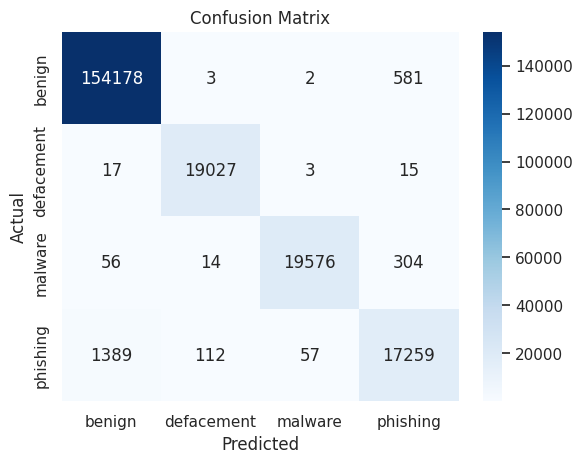

In [27]:
cm = confusion_matrix(y_test, pred_xgb_Best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

lgb = LGBMClassifier(
    max_depth=5,       
    num_leaves=31,         
    max_bin=63,          
    learning_rate=0.1,
    n_estimators=150,
    n_jobs=-1,
    device='cpu',       
    verbose=-1,      
    random_state=42
)
lgb.fit(X_train_final, y_train)
pred_lgb_best = lgb.predict(X_test_final)
acc_lgb = accuracy_score(y_test, pred_lgb_best)

print(f"LightGBM Accuracy: {acc_lgb:.4f}")
print("\n",classification_report(y_test, pred_lgb_best, target_names=class_names))

LightGBM Accuracy: 0.9812

               precision    recall  f1-score   support

      benign       0.99      0.99      0.99    154764
  defacement       0.98      0.99      0.99     19062
     malware       0.99      0.97      0.98     19950
    phishing       0.93      0.87      0.90     18817

    accuracy                           0.98    212593
   macro avg       0.97      0.96      0.96    212593
weighted avg       0.98      0.98      0.98    212593



In [29]:
lgb = LGBMClassifier(
    max_depth=5,         
    num_leaves=31,       
    max_bin=63,           
    learning_rate=0.1,
    n_jobs=-1,
    device='cpu',          
    verbose=-1,      
    random_state=42
) 
lgb.fit(X_train_Under, y_train_Under)
pred_lgb = lgb.predict(X_test_final)
acc_lgb2 = accuracy_score(y_test, pred_lgb)

print(f"LightGBM Accuracy: {acc_lgb2:.4f}")
print("\n",classification_report(y_test, pred_lgb, target_names=class_names))

LightGBM Accuracy: 0.9695

               precision    recall  f1-score   support

      benign       0.99      0.97      0.98    154764
  defacement       0.96      1.00      0.98     19062
     malware       0.99      0.97      0.98     19950
    phishing       0.80      0.92      0.85     18817

    accuracy                           0.97    212593
   macro avg       0.94      0.96      0.95    212593
weighted avg       0.97      0.97      0.97    212593



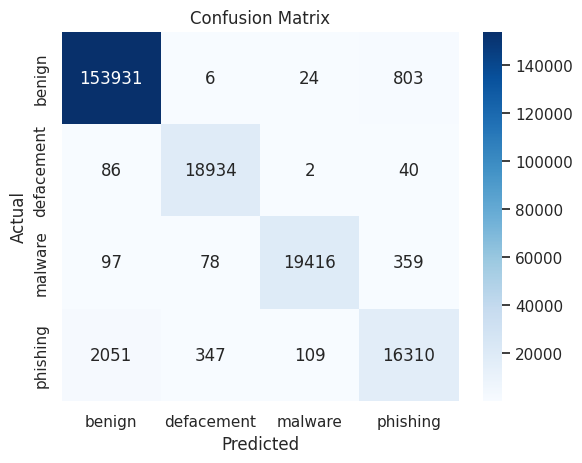

In [30]:
cm = confusion_matrix(y_test, pred_lgb_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier( 
                               learning_rate=0.1, 
                               depth=6, 
                               loss_function='MultiClass', 
                               verbose=0,
                               task_type="GPU",
                               border_count=32,
                               random_state=42)

cb_model.fit(X_train_final, y_train)
cb_pred_best = cb_model.predict(X_test_final)
accuracy_cb = accuracy_score(y_test, cb_pred_best)

print(f"CatBoost Accuracy: {accuracy_cb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, cb_pred_best, target_names=class_names))

CatBoost Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

      benign       0.99      1.00      0.99    154764
  defacement       0.98      0.99      0.99     19062
     malware       0.99      0.97      0.98     19950
    phishing       0.94      0.88      0.91     18817

    accuracy                           0.98    212593
   macro avg       0.97      0.96      0.97    212593
weighted avg       0.98      0.98      0.98    212593



In [32]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier( 
                               learning_rate=0.1, 
                               depth=6, 
                               loss_function='MultiClass', 
                               verbose=0,
                               task_type="GPU",
                               border_count=32,
                               random_state=42)

cb_model.fit(X_train_Under, y_train_Under)
y_pred_cb = cb_model.predict(X_test_final)
accuracy_cb2 = accuracy_score(y_test, y_pred_cb)

print(f"CatBoost Accuracy: {accuracy_cb2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cb, target_names=class_names))

CatBoost Accuracy: 0.9736

Classification Report:
              precision    recall  f1-score   support

      benign       0.99      0.98      0.98    154764
  defacement       0.97      1.00      0.98     19062
     malware       0.99      0.98      0.98     19950
    phishing       0.82      0.93      0.87     18817

    accuracy                           0.97    212593
   macro avg       0.94      0.97      0.96    212593
weighted avg       0.98      0.97      0.97    212593



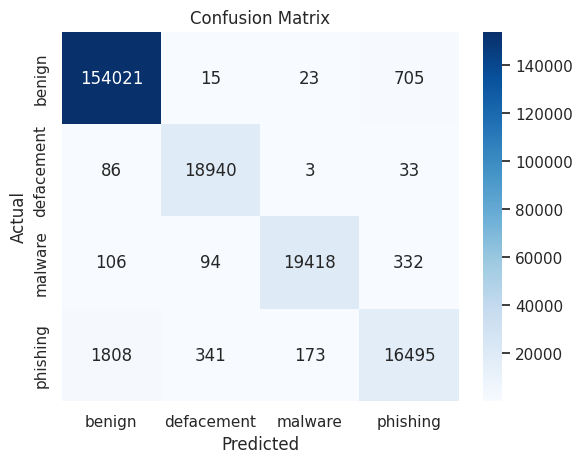

In [33]:
cm = confusion_matrix(y_test, cb_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

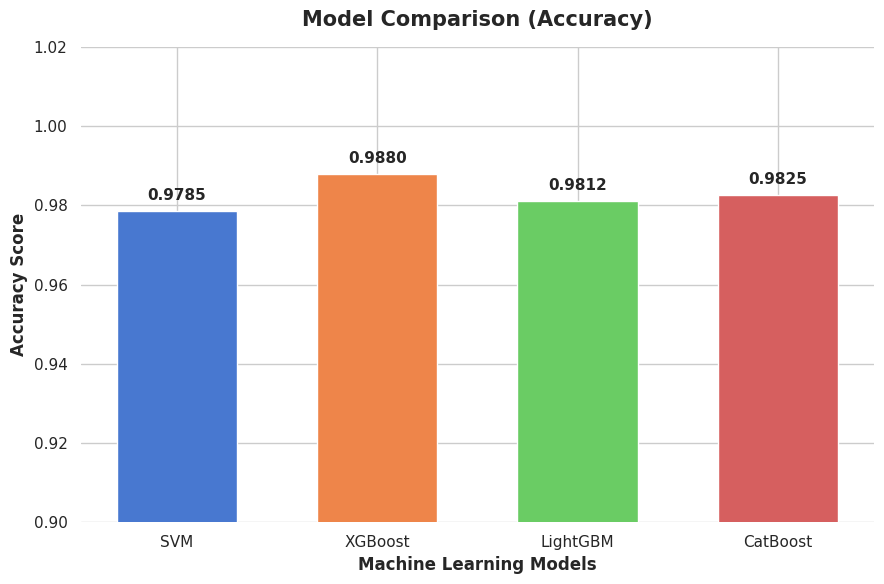

In [34]:
sns.set_theme(style="whitegrid")

models = ['SVM', 'XGBoost', 'LightGBM', 'CatBoost']
scores = [acc_svm, acc_xgb, acc_lgb, accuracy_cb]

plt.figure(figsize=(9, 6))
bars = plt.bar(models, scores, color=sns.color_palette("muted"), width=0.6)
min_score = min(scores)
plt.ylim(max(0, round(min_score - 0.05, 1)), 1.02)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 0.002, 
        f'{yval:.4f}',  
        ha='center', 
        va='bottom', 
        fontsize=11, 
        weight='bold'
    )

plt.title("Model Comparison (Accuracy)", fontsize=15, weight='bold', pad=15)
plt.ylabel("Accuracy Score", fontsize=12, weight='bold')
plt.xlabel("Machine Learning Models", fontsize=12, weight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()